## Linear Regression Proyect for Student Performace

### Setting the environment


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [4]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df = df.drop(columns='Extracurricular Activities')
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


#### Here I drop the non-numerical columns, as they can't be inclodud in linear regression models easily

### Lets start with the EDA (Exploratory Data Analysis)

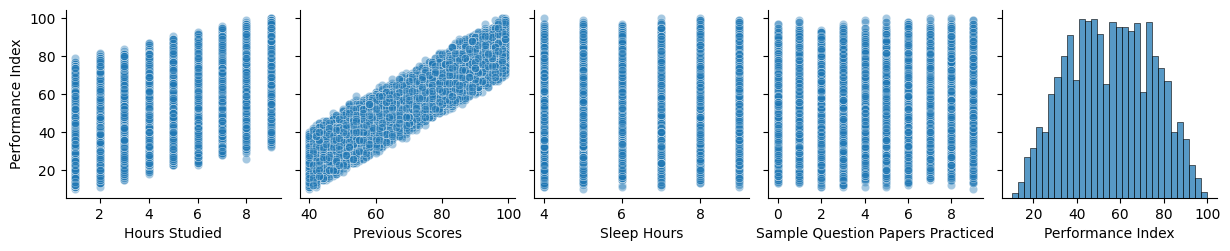

In [9]:
sns.pairplot(df, y_vars= ['Performance Index'] , plot_kws={'alpha': 0.4})

#### We can see that two of the variables, sleep hours and sample question papers practiced, show no perceptible direct correleation. On the other hand, hours study shows a slight correlation, and previous scores demonstrate a high correlation

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df[['Hours Studied','Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']]
y = df['Performance Index']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=990)

### Lets start training our Linear Regression Model

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lr = LinearRegression()
lr.fit(X_train, y=y_train)
lr.coef_

array([2.84793363, 1.01676649, 0.47659194, 0.18683393])

### Now let's test our model

In [17]:
predictions = lr.predict(X_test)

Text(0, 0.5, 'Actual Values')

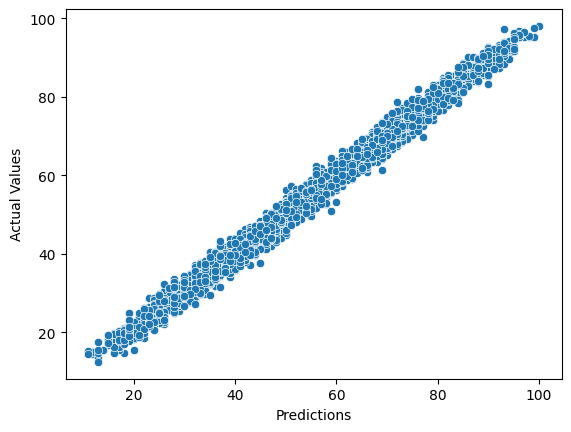

In [18]:
sns.scatterplot(x= y_test, y=predictions)
plt.xlabel('Predictions')
plt.ylabel('Actual Values')

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [20]:
print(f'Mean Absolute Error: {mean_absolute_error(y_test, predictions)}')
print(f'Mean Squared Error: {mean_squared_error(y_test, predictions)}')
print(f'RMSE: {math.sqrt(mean_squared_error(y_test, predictions))}')

Mean Absolute Error: 1.6278173113451024
Mean Squared Error: 4.176623636889366
RMSE: 2.0436789466277148


### Residuals
#### It is really important we chech the distribution of residuals in order to check for bias

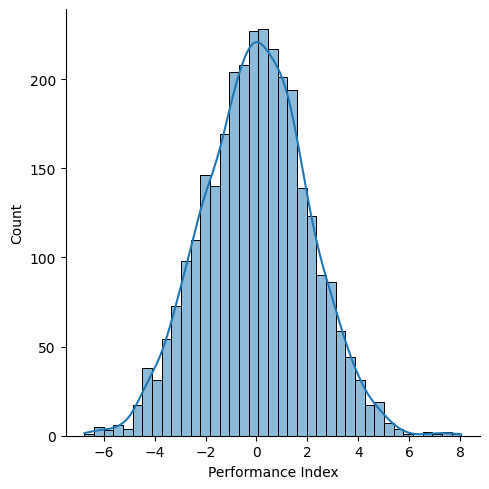

In [21]:
residuals = y_test - predictions
sns.displot(residuals, kde = True)